# EDA - Análisis Exploratorio de Datos: Factores de Riesgo de Obesidad

Este notebook sigue un flujo de trabajo estructurado para el análisis exploratorio (EDA), basado en las 5 preguntas de investigación del equipo. El objetivo es identificar la limpieza necesaria y las variables predictoras más fuertes antes del modelado, aplicando las mejores prácticas de Data Wrangling.

Importamos librerías estándar de la industria: `pandas` y `numpy` para manipulación de datos, `matplotlib` y `seaborn` para visualización. Usamos `%matplotlib inline` para que los gráficos se vean directamente en el notebook y `sns.set_theme` asegura un estilo limpio y uniforme en todas las gráficas.

In [1]:
# Importamos las librerías estándar de la industria
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# %matplotlib inline asegura que los gráficos se rendericen dentro del notebook
%matplotlib inline

# Configuración estética profesional
sns.set_theme(style="whitegrid", context="notebook")

### 1. Carga de Datos y Limpieza Avanzada
- Observaremos que todas las columnas adoptan el estándar `snake_case`. 
- Aplicar minúsculas y eliminar caracteres especiales nos asegura que no habrá errores tipográficos al llamar a las variables durante el modelado.
- Mantenemos `df_raw` intacto y trabajamos sobre una copia para no alterar los datos originales.
- Vemos las primeras filas `head()`, las dimensiones `shape()`y los tipos de datos `info()`, además de un resumen estadístico `describe()`.

In [2]:
np.random.seed(42) 

# Cargar dataset original y copiarlo
df_raw = pd.read_csv('../data/raw/ObesityDataSet.csv')
df = df_raw.copy()

# Limpieza avanzada de nombres de columnas
df.columns = (
    df.columns
    .str.strip()             # Quita espacios al inicio/final
    .str.lower()             # Convierte a minúsculas
    .str.replace(' ', '_')   # Reemplaza espacios internos por guiones bajos
    .str.replace(r'[^\w]', '', regex=True)  # Elimina caracteres especiales
)

# Comprobación de los nuevos nombres de columnas (Ejemplo: "NObeyesdad" → "nobeyesdad")
print("Columnas estandarizadas:\n", df.columns.tolist()) # .tolist() -> convierte el index en una lista normal de python

# Revisiones rápidas
print('\n--- Dimensiones del Dataset ---')
print('Filas y Columnas:', df.shape)

print('\n--- Información General ---')
print(df.info())

# Resumen estadístico (media, min, max, cuartiles)
display(df.describe()) # display -> tabla elegante

Columnas estandarizadas:
 ['gender', 'age', 'height', 'weight', 'family_history_with_overweight', 'favc', 'fcvc', 'ncp', 'caec', 'smoke', 'ch2o', 'scc', 'faf', 'tue', 'calc', 'mtrans', 'nobeyesdad']

--- Dimensiones del Dataset ---
Filas y Columnas: (2111, 17)

--- Información General ---
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          2111 non-null   str    
 1   age                             2111 non-null   float64
 2   height                          2111 non-null   float64
 3   weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   favc                            2111 non-null   str    
 6   fcvc                            2111 non-null   float64
 7   ncp                             2111 non-null   float64
 8  

,age,height,weight,fcvc,ncp,ch2o,faf,tue
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


- Tras aplicar la limpieza avanzada, las columnas quedan estandarizadas (`Age` → `age`, `NObeyesdad` → `nobeyesdad`). Al analizar `df.describe()`, observamos que `age` presenta un rango entre 14 y 61 años, mientras que `weight` oscila entre 39 kg y 173 kg, sin valores matemáticamente inconsistentes.

- Este análisis también permite detectar posibles valores atípicos visibles y observar que variables como `age` y `weight` contienen decimales muy precisos, lo que sugiere que el dataset ha sido generado o enriquecido mediante técnicas sintéticas, probablemente utilizando métodos como `SMOTE`.


### 2. Detección de Nulos

In [3]:
# Contamos valores faltantes (NaN)
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
gender                            0
age                               0
height                            0
weight                            0
family_history_with_overweight    0
favc                              0
fcvc                              0
ncp                               0
caec                              0
smoke                             0
ch2o                              0
scc                               0
faf                               0
tue                               0
calc                              0
mtrans                            0
nobeyesdad                        0
dtype: int64


El output es todo ceros (0). Es un dataset limpio de nulos. <br>
Contamos los valores nulos por columna y encontramos que no hay ninguno. Esto es importante porque los modelos de Machine Learning fallan si encuentran NaN. En este caso, no necesitamos aplicar técnicas de imputación.

### 3. Pregunta 1: Distribución del Target (`nobeyesdad`)
Observamos la longitud de las barras. ¿Hay clases minoritarias?

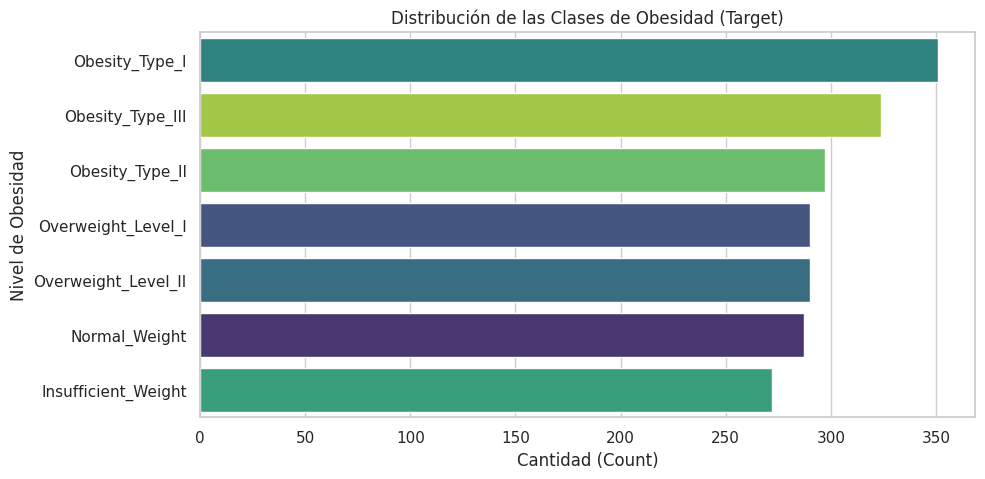

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(y='nobeyesdad', data=df, 
              order=df['nobeyesdad'].value_counts().index, 
              hue='nobeyesdad', palette='viridis', legend=False) # hue y legend -> para evitar warning deprecated futura en versión de seaborn actual
plt.title('Distribución de las Clases de Obesidad (Target)')
plt.xlabel('Cantidad (Count)')
plt.ylabel('Nivel de Obesidad')
plt.show()

Visualizamos la distribución de las clases de obesidad con un gráfico de barras horizontal. Observamos que cada clase tiene aproximadamente 300 registros, lo que indica que el dataset está perfectamente equilibrado. Esto nos evitará aplicar técnicas de remuestreo sintético (SMOTE) en el modelado.

### 4. Pregunta 2: Segmentación Física (Edad y Peso)
Observamos si las cajas de los diagramas se solapan o forman escaleras.

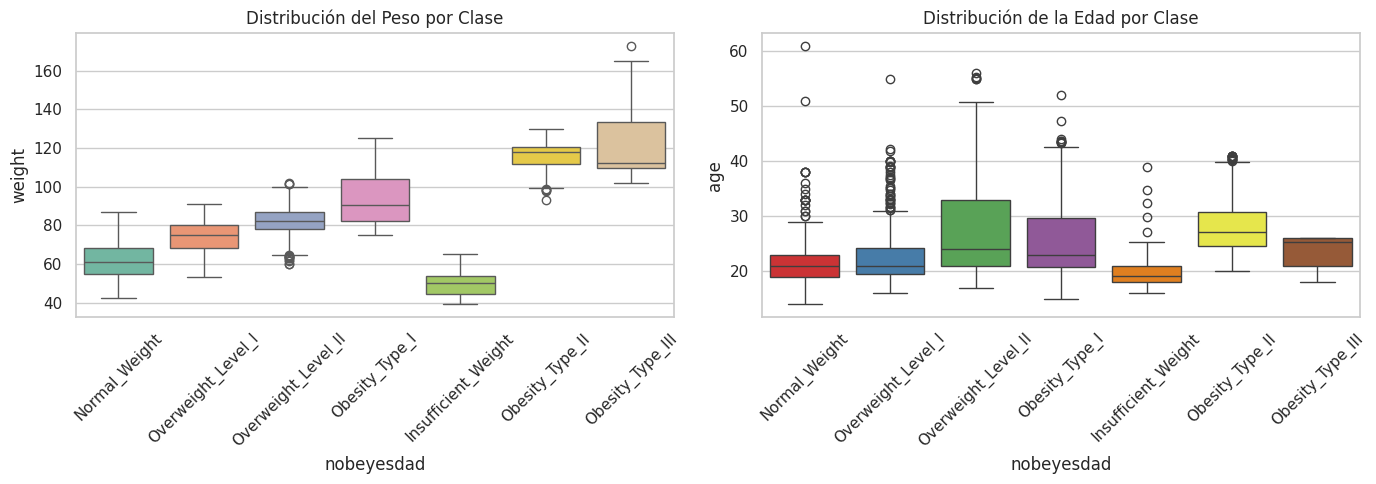

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de Peso
sns.boxplot(ax=axes[0], x='nobeyesdad', y='weight', data=df,
            hue='nobeyesdad', palette='Set2', legend=False) # hue y legend -> lo mismo de antes. Use la variable `hue` para los colores y `legend`para no duplicar información
axes[0].set_title('Distribución del Peso por Clase')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot de Edad
sns.boxplot(ax=axes[1], x='nobeyesdad', y='age', data=df,
            hue='nobeyesdad', palette='Set1', legend=False) # hue y legend
axes[1].set_title('Distribución de la Edad por Clase')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Usamos boxplots para analizar `age` y `weight` por clase. Vemos que el `weight` segmenta las clases casi a la perfección (formando una escalera ascendente), lo que convierte en un predictor muy fuerte. En cambio, la `age`  tiene una mediana similar entre clases, pero aparecen muchos outliers por encima de los 40. Estos valores atípicos podrían sesgar los modelos, por lo que planificamos limpiarlos más adelante.

### 5. Pregunta 3: Impacto del Entorno Familiar

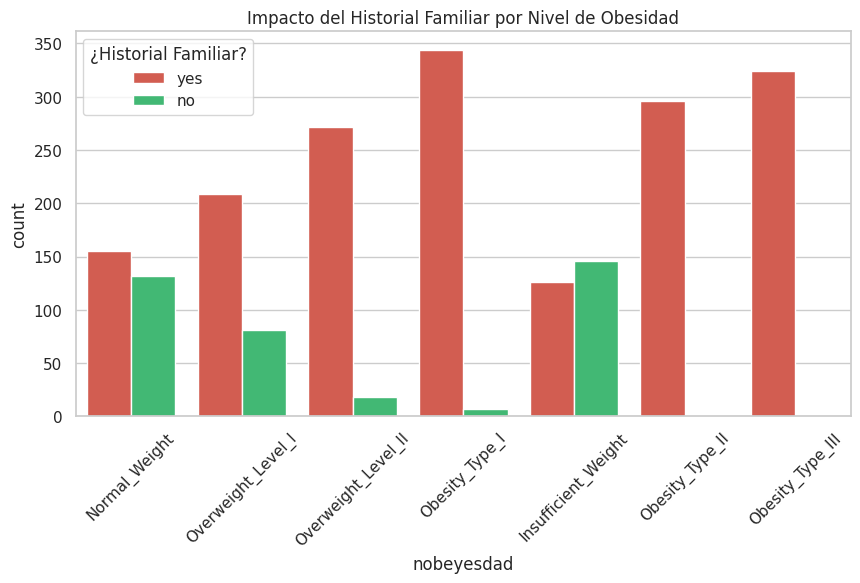

In [6]:
plt.figure(figsize=(10, 5))
sns.countplot(x='nobeyesdad', hue='family_history_with_overweight', data=df,
              palette={'yes': '#e74c3c', 'no': '#2ecc71'}) 
plt.title('Impacto del Historial Familiar por Nivel de Obesidad')
plt.xticks(rotation=45)
plt.legend(title='¿Historial Familiar?')
plt.show()

Analizamos la variable `family_history_with_overweight`  y observamos que en `obesity_type II y III` casi todos los registros tienen historial familiar (casi 100% registros en rojo). Esto indica que es una variable determinante y probablemente será una de nuestras **Top Features** para el modelo. 

### 6. Pregunta 4: Matriz de Correlación

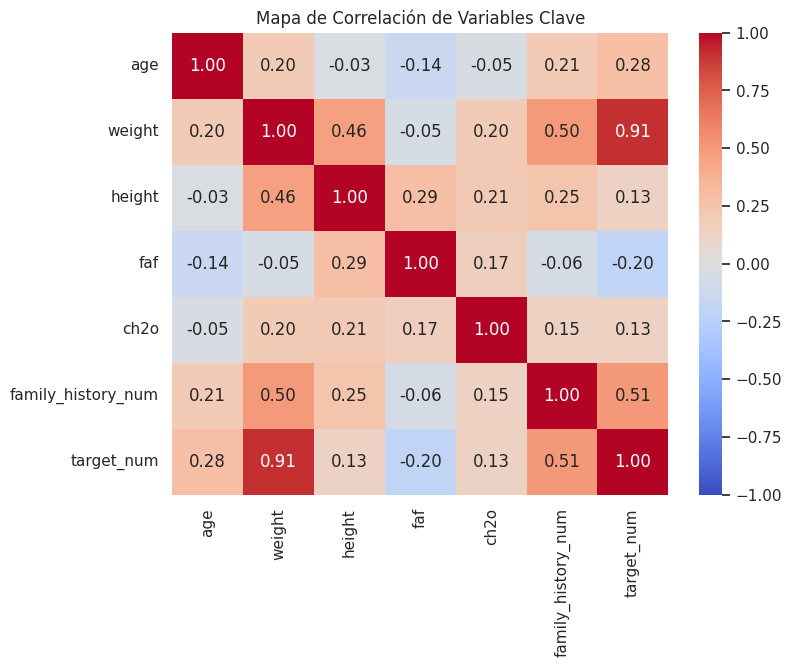

In [7]:
# Mapeo de texto a números manteniendo el estándar snake_case
diccionario_obesidad = {
    'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2,
    'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6
}

# Creación de nuevas columnas limpias
df['target_num'] = df['nobeyesdad'].map(diccionario_obesidad)
df['family_history_num'] = df['family_history_with_overweight'].map({'yes': 1, 'no': 0})

# Selección de variables
columnas_corr =['age', 'weight', 'height', 'faf', 'ch2o', 'family_history_num', 'target_num']
corr = df[columnas_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Correlación de Variables Clave')
plt.show()

Para calcular correlaciones, mapeamos variables categóricas a números. El `weight` tiene una correlación de **0.91** con el Target, el `family_history_num` de **0.51**, y  el estilo de vida, `faf`  tiene una correlación negativa **-0.20**, actuando como protector. Mientras que el consumo de agua `ch2o` tiene una correlación ligeramente positiva **0.13**, explicable porque las personas con mayor peso requieren más hidratación por pura necesidad biológica.

### 7. Pregunta 5: Errores y Outliers (Scatterplot)

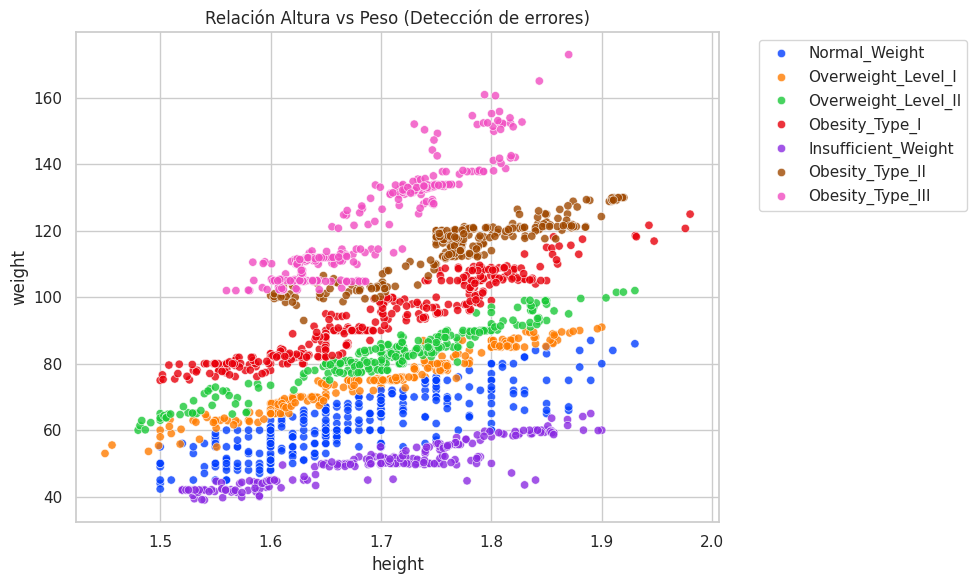

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='height', y='weight', hue='nobeyesdad', data=df, alpha=0.8, palette='bright')
plt.title('Relación Altura vs Peso (Detección de errores)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Visualizamos `height` vs `weight`y notamos que los datos, las bandas de colores, siguen la curva del IMC. No existen errores de entrada humanos graves en las métricas de altura y peso (como alguien muy liviano con altura muy alta), lo que confirma que estas variables son confiables. Los outliers principales siguen estando en `age`.

### 8. Tratamiento de Datos y Guardado

In [9]:
# Filtramos los outliers detectados en los boxplots limitando la edad al percentil 99
limite_superior_edad = df['age'].quantile(0.99)
df_limpio = df[df['age'] <= limite_superior_edad].copy()

print(f"Límite de edad aplicado: {limite_superior_edad:.1f} años")

# Limpiamos las columnas auxiliares
df_limpio.drop(columns=['target_num', 'family_history_num'], inplace=True)

# Exportar a CSV
df_limpio.to_csv('../data/processed/ObesityDataSet_limpio_m.csv', index=False)
print(f"Dataset limpio guardado. Pasamos de {df.shape[0]} a {df_limpio.shape[0]} registros listos para el modelo.")

Límite de edad aplicado: 43.6 años
Dataset limpio guardado. Pasamos de 2111 a 2089 registros listos para el modelo.


Filtramos el 1% superior de edades para limpiar outliers severos sin perder demasiada información. El dataset resultante (df_limpio) se guarda en un nuevo CSV listo para modelado. Esto asegura un flujo de trabajo reproducible y preparado para entrenar modelos confiables.

### 9. Conclusiones finales

- El EDA sigue un flujo claro: Carga --> Quick Checks --> Nulos --> Distribución --> Segmentación --> Entrono Familiar --> Correlaciones --> Outliers --> Limpieza --> Guardado <br>
- Identificado variables predictoras clave: `weight`, `family_history_with_overweight`, `faf`.
- El dataset está equilibrado y limpio, listo para el modelado.
- Los outliers de `age`han sido tratados, dejando el CSV preparado para entrenar modelos sin sesgos.